# Project 3 - Connect-4 Reinforcement Learning

- **Course:** Optimization II (R M 294)  
- **Group 3:** `Abhiroop Kumar, Aileen Li, Jacob Embleton, Riju Hariharan`  
- **Base model M1:** `Riju_CNN`  

## Executive Objective

This notebook evaluates whether reinforcement learning can improve Connect-4 playing strategies for a board game company. The workflow starts from a Project 1 neural network that imitates MCTS-style play, then applies two reinforcement learning approaches:

1. **Policy Gradient (PG):** improves the base model through self-play and adversarial training.
2. **Deep Q-Network (DQN):** learns state-action values using epsilon-greedy exploration, replay memory, and a target network.

The final sections compare the original model, PG-improved model, and DQN agent using win rates, match length, move preferences, and representative board-state decisions.

## 1. Project Requirements and Approach

The project asks us to explore reinforcement learning for Connect-4 using self-play. The required workflow is:

- Choose one Project 1 model as the base model `M1`.
- Improve `M1` with a policy-gradient strategy against teammate models and historical snapshots.
- Train a DQN using an epsilon-greedy strategy against randomly selected opponents.
- Compare PG, DQN, original M1, teammate models, and baselines.
- Explain what worked well, what did not, and whether RL expertise would be valuable for the company.

The implementation below keeps the problem framing close to class concepts: state variables, actions, rewards, Bellman-style value updates, exploration vs exploitation, and adversarial self-play.


## 2. Setup and Reproducibility


In [1]:
import numpy as np
import tensorflow as tf

print("numpy:", np.__version__)
print("tensorflow:", tf.__version__)


c:\Users\Abhiroop Kumar\miniconda3\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


numpy: 2.1.3
tensorflow: 2.20.0


## 3. Connect-4 Environment

The environment is intentionally lightweight and transparent. This helps the evaluator understand exactly how legal moves, wins, draws, and board encodings are handled.

**State:** a `6 x 7` board.  
**Action:** select one of seven columns.  
**Transition:** drop a piece into the selected column, then switch turns.  
**Reward:** win, loss, or draw at terminal states.  
**Model input:** two-channel board representation from the current player's perspective.


In [2]:
# ----- Constants -----
ROWS = 6
COLS = 7
EMPTY = 0
P1 = 1
P2 = -1


# ----- Core board operations -----

def new_board():
    """Return a fresh empty board."""
    return np.zeros((ROWS, COLS), dtype=np.int8)


def legal_moves(board):
    """Return list of column indices where a piece can be dropped."""
    return [c for c in range(COLS) if board[0, c] == EMPTY]


def is_legal(board, col):
    """Check if a column is a legal move."""
    return 0 <= col < COLS and board[0, col] == EMPTY


def drop_piece(board, col, player):
    """
    Drop a piece for `player` into `col`. Returns a NEW board (does not mutate).
    Raises ValueError if column is full or invalid.
    """
    if not is_legal(board, col):
        raise ValueError(f"Illegal move: column {col} is full or invalid")
    new = board.copy()
    for row in range(ROWS - 1, -1, -1):
        if new[row, col] == EMPTY:
            new[row, col] = player
            return new
    raise ValueError(f"Column {col} is full")


def check_win(board, player):
    """Check if `player` has 4 in a row anywhere on the board."""
    # Horizontal
    for r in range(ROWS):
        for c in range(COLS - 3):
            if all(board[r, c + i] == player for i in range(4)):
                return True
    # Vertical
    for r in range(ROWS - 3):
        for c in range(COLS):
            if all(board[r + i, c] == player for i in range(4)):
                return True
    # Diagonal down-right (\\)
    for r in range(ROWS - 3):
        for c in range(COLS - 3):
            if all(board[r + i, c + i] == player for i in range(4)):
                return True
    # Diagonal up-right (/)
    for r in range(3, ROWS):
        for c in range(COLS - 3):
            if all(board[r - i, c + i] == player for i in range(4)):
                return True
    return False


def is_draw(board):
    """Board is a draw if it's full and nobody won. Caller should check win first."""
    return not any(board[0, c] == EMPTY for c in range(COLS))


def game_status(board):
    """
    Returns:
        1  if P1 won
        -1 if P2 won
        0  if draw
        None if game is ongoing
    """
    if check_win(board, P1):
        return 1
    if check_win(board, P2):
        return -1
    if is_draw(board):
        return 0
    return None


# ----- Model input encoding -----

def board_to_2ch(board, current_player):
    """
    Convert (6,7) board to (6,7,2) input for the model, from the perspective
    of `current_player`. Channel 0: my pieces. Channel 1: opponent's pieces.
    """
    mine = (board == current_player).astype(np.float32)
    theirs = (board == -current_player).astype(np.float32)
    return np.stack([mine, theirs], axis=-1)


def board_to_seq(board, current_player):
    """Convert (6,7) board to (42,2) sequence input for transformer models."""
    return board_to_2ch(board, current_player).reshape(42, 2)


# ----- Tactical helpers (for making opponents stronger) -----

def find_winning_move(board, player):
    """Return a column where `player` can win immediately, or None."""
    for col in legal_moves(board):
        if check_win(drop_piece(board, col, player), player):
            return col
    return None


def find_blocking_move(board, player):
    """
    Return a column where `player` must play to block the opponent's immediate
    win, or None.
    """
    opp = -player
    for col in legal_moves(board):
        if check_win(drop_piece(board, col, opp), opp):
            return col
    return None


def non_losing_moves(board, player):
    """
    Return list of legal moves that do NOT immediately hand the opponent a win
    on their next turn. Falls back to all legal moves if every option loses.
    """
    safe = []
    for col in legal_moves(board):
        after_mine = drop_piece(board, col, player)
        if check_win(after_mine, player):
            safe.append(col)
            continue
        opp = -player
        opp_wins = False
        for opp_col in legal_moves(after_mine):
            if check_win(drop_piece(after_mine, opp_col, opp), opp):
                opp_wins = True
                break
        if not opp_wins:
            safe.append(col)
    return safe if safe else legal_moves(board)


# ----- Display -----

def render(board):
    """Pretty-print the board for debugging."""
    symbols = {EMPTY: ".", P1: "X", P2: "O"}
    lines = []
    for row in board:
        lines.append(" ".join(symbols[v] for v in row))
    lines.append(" ".join(str(c) for c in range(COLS)))
    return "\n".join(lines)


In [3]:
# Quick sanity test of the game logic
b = new_board()
print("Empty board:")
print(render(b))
print()

# P1 builds a vertical in column 3
for _ in range(3):
    b = drop_piece(b, 3, P1)
    b = drop_piece(b, 4, P2)
print("After 3 moves each:")
print(render(b))
print(f"P1 winning move: {find_winning_move(b, P1)}  (should be 3)")
print(f"P2 blocking move: {find_blocking_move(b, P2)}  (should be 3)")


Empty board:
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
0 1 2 3 4 5 6

After 3 moves each:
. . . . . . .
. . . . . . .
. . . . . . .
. . . X O . .
. . . X O . .
. . . X O . .
0 1 2 3 4 5 6
P1 winning move: 3  (should be 3)
P2 blocking move: 3  (should be 3)


## 4. Model Loading and Move Selection

This section loads teammate models and standardizes move selection. The same interface supports:

- deterministic evaluation with `argmax`
- stochastic play for PG rollouts
- epsilon-greedy play for DQN rollouts
- tactical overrides for immediate wins and blocks when creating stronger opponents

This design lets every trained or baseline agent be evaluated under the same match runner.


In [4]:
# ----- Model loading -----

def load_model(path):
    """
    Load a Keras model from .keras or .h5 file.
    Auto-detects input kind and attaches _input_kind and _name_tag attributes.
    """
    try:
        model = tf.keras.models.load_model(path, compile=False, safe_mode=False)
    except TypeError:
        # fallback for older TensorFlow/Keras versions
        tf.keras.config.enable_unsafe_deserialization()
        model = tf.keras.models.load_model(path, compile=False)

    input_shape = model.input_shape

    if len(input_shape) == 4 and input_shape[1:] == (6, 7, 2):
        model._input_kind = "cnn"
    elif len(input_shape) == 3 and input_shape[1:] == (42, 2):
        model._input_kind = "transformer"
    else:
        raise ValueError(
            f"Unrecognized input shape {input_shape} for model at {path}. "
            f"Expected (None,6,7,2) or (None,42,2)."
        )

    model._name_tag = path.split("/")[-1]
    return model


def encode_board(board, current_player, model):
    """Encode a board for a specific model based on its input kind."""
    if model._input_kind == "cnn":
        x = board_to_2ch(board, current_player)
    else:
        x = board_to_seq(board, current_player)
    return x[np.newaxis, ...]


# ----- Raw model inference -----

def predict_probs(board, current_player, model):
    """Get raw probability distribution over 7 columns. Does NOT mask illegal."""
    x = encode_board(board, current_player, model)
    probs = model(x, training=False).numpy()[0]
    return probs


def mask_illegal(probs, board):
    """Zero out probs for illegal columns and renormalize."""
    legal = legal_moves(board)
    masked = np.zeros(COLS, dtype=np.float32)
    for c in legal:
        masked[c] = probs[c]
    s = masked.sum()
    if s > 0:
        return masked / s
    uniform = np.zeros(COLS, dtype=np.float32)
    for c in legal:
        uniform[c] = 1.0 / len(legal)
    return uniform


# ----- Move selection -----

def get_move(
    board,
    current_player,
    model,
    mode="stochastic",
    epsilon=0.1,
    uniform_mix=0.0,
    force_win=False,
    block_loss=False,
    rng=None,
):
    """
    Pick a column for `current_player` using `model`.

    Parameters
    ----------
    mode : "argmax", "stochastic", or "epsilon"
    epsilon : exploration rate for "epsilon" mode
    uniform_mix : [0,1]. Blends uniform with model probs for exploration.
    force_win : play immediately winning moves (use for strong opponents)
    block_loss : block immediate losses (use for strong opponents)

    Returns
    -------
    col : int, the chosen column
    probs : (7,) masked probability distribution used for selection
    """
    if rng is None:
        rng = np.random.default_rng()

    # Tactical overrides first
    if force_win:
        w = find_winning_move(board, current_player)
        if w is not None:
            probs = np.zeros(COLS, dtype=np.float32)
            probs[w] = 1.0
            return w, probs
    if block_loss:
        b = find_blocking_move(board, current_player)
        if b is not None:
            probs = np.zeros(COLS, dtype=np.float32)
            probs[b] = 1.0
            return b, probs

    raw = predict_probs(board, current_player, model)
    probs = mask_illegal(raw, board)

    if uniform_mix > 0.0:
        legal = legal_moves(board)
        u = np.zeros(COLS, dtype=np.float32)
        for c in legal:
            u[c] = 1.0 / len(legal)
        probs = (1.0 - uniform_mix) * probs + uniform_mix * u
        probs = probs / probs.sum()

    if mode == "argmax":
        col = int(np.argmax(probs))
    elif mode == "stochastic":
        col = int(rng.choice(COLS, p=probs))
    elif mode == "epsilon":
        if rng.random() < epsilon:
            legal = legal_moves(board)
            col = int(rng.choice(legal))
        else:
            col = int(np.argmax(probs))
    else:
        raise ValueError(f"Unknown mode: {mode}")

    return col, probs


## 5. Evaluation Framework

The `Agent` abstraction makes model-to-model games, baseline checks, and final tournaments consistent. The match runner alternates first-player advantage, which is important because Connect-4 is sensitive to move order.


In [5]:
# ----- Agent interface -----

class Agent:
    """Uniform interface for anything that picks a Connect-4 move."""
    name = "Agent"

    def choose(self, board, current_player, rng):
        raise NotImplementedError


class ModelAgent(Agent):
    """Wraps a loaded Keras model + selection mode into an Agent."""

    def __init__(
        self,
        model,
        mode="argmax",
        epsilon=0.0,
        uniform_mix=0.0,
        force_win=False,
        block_loss=False,
        name=None,
    ):
        self.model = model
        self.mode = mode
        self.epsilon = epsilon
        self.uniform_mix = uniform_mix
        self.force_win = force_win
        self.block_loss = block_loss
        self.name = name or getattr(model, "_name_tag", "model")

    def choose(self, board, current_player, rng):
        col, _ = get_move(
            board,
            current_player,
            self.model,
            mode=self.mode,
            epsilon=self.epsilon,
            uniform_mix=self.uniform_mix,
            force_win=self.force_win,
            block_loss=self.block_loss,
            rng=rng,
        )
        return col


class RandomAgent(Agent):
    """Picks uniformly from legal moves. Useful as a sanity baseline."""
    name = "random"

    def choose(self, board, current_player, rng):
        legal = legal_moves(board)
        return int(rng.choice(legal))


# ----- Single game -----

def play_game(agent_p1, agent_p2, rng=None, max_moves=42, record_boards=False):
    """
    Play one game. agent_p1 plays as P1 (moves first), agent_p2 plays as P2.
    Returns dict with result, num_moves, boards (if recorded), moves.
    """
    if rng is None:
        rng = np.random.default_rng()

    board = new_board()
    current = P1
    agents = {P1: agent_p1, P2: agent_p2}
    boards = [board.copy()] if record_boards else None
    moves = []

    for _ in range(max_moves):
        agent = agents[current]
        col = agent.choose(board, current, rng)
        board = drop_piece(board, col, current)
        moves.append((current, col))
        if record_boards:
            boards.append(board.copy())

        status = game_status(board)
        if status is not None:
            return {
                "result": status,
                "num_moves": len(moves),
                "boards": boards,
                "moves": moves,
            }
        current = -current

    return {"result": 0, "num_moves": len(moves), "boards": boards, "moves": moves}


# ----- Match -----

def play_match(agent_a, agent_b, n_games=50, alternate=True, rng=None, verbose=False):
    """
    Play n_games between agent_a and agent_b, alternating who goes first.
    Returns summary dict with wins, draws, avg game length, etc.
    """
    if rng is None:
        rng = np.random.default_rng()

    a_wins = 0
    b_wins = 0
    draws = 0
    total_moves = 0
    a_wins_as_p1 = 0
    a_wins_as_p2 = 0

    for g in range(n_games):
        a_is_p1 = (g % 2 == 0) if alternate else True

        if a_is_p1:
            result = play_game(agent_a, agent_b, rng=rng)
            if result["result"] == 1:
                a_wins += 1
                a_wins_as_p1 += 1
            elif result["result"] == -1:
                b_wins += 1
            else:
                draws += 1
        else:
            result = play_game(agent_b, agent_a, rng=rng)
            if result["result"] == -1:
                a_wins += 1
                a_wins_as_p2 += 1
            elif result["result"] == 1:
                b_wins += 1
            else:
                draws += 1

        total_moves += result["num_moves"]
        if verbose and (g + 1) % max(1, n_games // 10) == 0:
            print(f"  Game {g+1}/{n_games}: {agent_a.name} {a_wins}-{b_wins}-{draws} {agent_b.name}")

    return {
        "agent_a": agent_a.name,
        "agent_b": agent_b.name,
        "n_games": n_games,
        "a_wins": a_wins,
        "b_wins": b_wins,
        "draws": draws,
        "a_win_rate": a_wins / n_games,
        "b_win_rate": b_wins / n_games,
        "draw_rate": draws / n_games,
        "avg_moves": total_moves / n_games,
        "a_wins_as_p1": a_wins_as_p1,
        "a_wins_as_p2": a_wins_as_p2,
    }


def format_match_summary(summary):
    """Pretty-print a match summary dict."""
    a, b = summary["agent_a"], summary["agent_b"]
    lines = [
        f"{a} vs {b}  ({summary['n_games']} games)",
        f"  {a}: {summary['a_wins']} wins ({summary['a_win_rate']*100:.1f}%)",
        f"  {b}: {summary['b_wins']} wins ({summary['b_win_rate']*100:.1f}%)",
        f"  Draws: {summary['draws']} ({summary['draw_rate']*100:.1f}%)",
        f"  Avg game length: {summary['avg_moves']:.1f} moves",
        f"  {a} as P1: {summary['a_wins_as_p1']} wins | as P2: {summary['a_wins_as_p2']} wins",
    ]
    return "\n".join(lines)


# ----- Round-robin -----

def round_robin(agents, n_games_per_pair=20, rng=None, verbose=False):
    """
    Play every agent vs every other agent. Returns dict with summaries, matrix,
    and agent_names (matrix[i,j] = agent i's win rate vs agent j).
    """
    if rng is None:
        rng = np.random.default_rng()

    n = len(agents)
    results = {}
    win_rate_matrix = np.zeros((n, n))

    for i, a in enumerate(agents):
        for j, b in enumerate(agents):
            if i == j:
                win_rate_matrix[i, j] = np.nan
                continue
            if verbose:
                print(f"\n{a.name} vs {b.name}")
            summary = play_match(a, b, n_games=n_games_per_pair, rng=rng, verbose=False)
            results[(a.name, b.name)] = summary
            win_rate_matrix[i, j] = summary["a_win_rate"]

    return {
        "summaries": results,
        "matrix": win_rate_matrix,
        "agent_names": [a.name for a in agents],
    }


## 6. Sanity Check

Before using trained neural networks, the environment is tested with random agents. This confirms that legal moves, win detection, draw detection, and alternating turns work correctly.


In [6]:
rng = np.random.default_rng(42)
r1 = RandomAgent(); r1.name = "random_A"
r2 = RandomAgent(); r2.name = "random_B"

summary = play_match(r1, r2, n_games=200, rng=rng)
print(format_match_summary(summary))


random_A vs random_B  (200 games)
  random_A: 89 wins (44.5%)
  random_B: 110 wins (55.0%)
  Draws: 1 (0.5%)
  Avg game length: 21.3 moves
  random_A as P1: 50 wins | as P2: 39 wins


## 7. Complete Project Workflow

The remaining sections implement the full project workflow.

**Important modeling choice:** This notebook uses `Riju_CNN` as the base model `M1`. The original M1, PG-improved M1, and DQN agent are compared in the final evaluation.


In [7]:
# ----- Additional setup -----
import os, random, math, collections
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

SEED = 2942
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

ARTIFACT_DIR = Path("project3_artifacts")
PLOT_DIR = ARTIFACT_DIR / "plots"
MODEL_OUT_DIR = ARTIFACT_DIR / "trained_models"
for d in [ARTIFACT_DIR, PLOT_DIR, MODEL_OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Artifacts folder:", ARTIFACT_DIR.resolve())


Artifacts folder: C:\ABHIROOP_CHUWI_DATA\STUDIES\Optimization II (R M 294)\Projects\Project 3\Solution\project3_artifacts


In [8]:
# ----- Model paths -----
# Put the three model files in the same folder as this notebook.
# The /mnt/data option is only for this generated workspace and is harmless elsewhere.

MODEL_DIR_CANDIDATES = [Path("."), Path("/mnt/data")]

MODEL_FILENAMES = {
    "Jake_M1_original": "jake_cnn_best.keras",              # REQUIRED base M1
    "Abhiroop_CNN": "abhiroop_CNN_v2_deep_best.h5",
    # "Aileen_CNN": "aileen_connect4_cnn_final.h5",  # excluded: loading model crashes kernel due to Lambda layer (same with `aileen_connect4_cnn_final.keras` as well)
    "Riju_CNN": "Riju_cnn_model_2.h5"
}

def resolve_model_path(filename):
    for base in MODEL_DIR_CANDIDATES:
        candidate = base / filename
        if candidate.exists():
            return str(candidate)
    raise FileNotFoundError(f"Could not find {filename}. Put it beside the notebook or update MODEL_DIR_CANDIDATES.")

MODEL_PATHS = {name: resolve_model_path(fname) for name, fname in MODEL_FILENAMES.items()}
MODEL_PATHS


{'Jake_M1_original': 'jake_cnn_best.keras',
 'Abhiroop_CNN': 'abhiroop_CNN_v2_deep_best.h5',
 'Riju_CNN': 'Riju_cnn_model_2.h5'}

_**Note:** Aileen’s baseline model was excluded from training/evaluation because its saved .h5 artifact contained a Lambda layer that caused kernel-level deserialization failure in the local TensorFlow/Keras environment._

**Error:**  
> The Kernel crashed while executing code in the current cell or a previous cell.  
> Please review the code in the cell(s) to identify a possible cause of the failure.  
> Click <a href='https://aka.ms/vscodeJupyterKernelCrash'>here</a> for more info.  

### 7.1 Load Project 1 Models

Three Project 1 models are loaded when available in the notebook directory. Aileen's saved artifact is left out because the local TensorFlow/Keras environment caused a Lambda-layer deserialization crash during testing. The workflow therefore uses Jake, Abhiroop, and Riju models.

The selected base model is:

**`M1 = Riju_CNN`**


In [9]:
# ----- Load baseline models -----
baseline_models = {}
for name, path in MODEL_PATHS.items():
    model = load_model(path)
    model._name_tag = name
    baseline_models[name] = model
    print(f"{name}: input_kind={model._input_kind}, input_shape={model.input_shape}, output_shape={model.output_shape}")

M1_NAME = "Riju_CNN"
M1_original = baseline_models[M1_NAME]
print("\nBase M1 model:", M1_NAME)


Jake_M1_original: input_kind=cnn, input_shape=(None, 6, 7, 2), output_shape=(None, 7)
Abhiroop_CNN: input_kind=cnn, input_shape=(None, 6, 7, 2), output_shape=(None, 7)
Riju_CNN: input_kind=cnn, input_shape=(None, 6, 7, 2), output_shape=(None, 7)

Base M1 model: Riju_CNN


In [10]:
# ----- Extra agent wrappers -----
class DQNAgent(Agent):
    """Agent wrapper for a Q-network that outputs 7 action values."""
    def __init__(self, q_model, name="DQN", epsilon=0.0, force_win=False, block_loss=False):
        self.q_model = q_model
        self.name = name
        self.epsilon = epsilon
        self.force_win = force_win
        self.block_loss = block_loss

    def choose(self, board, current_player, rng):
        if self.force_win:
            w = find_winning_move(board, current_player)
            if w is not None:
                return int(w)
        if self.block_loss:
            b = find_blocking_move(board, current_player)
            if b is not None:
                return int(b)

        legal = legal_moves(board)
        if rng.random() < self.epsilon:
            return int(rng.choice(legal))

        x = board_to_2ch(board, current_player)[np.newaxis, ...]
        q = self.q_model(x, training=False).numpy()[0]
        masked_q = np.full(COLS, -1e9, dtype=np.float32)
        for c in legal:
            masked_q[c] = q[c]
        return int(np.argmax(masked_q))


class TacticalRandomAgent(Agent):
    """Random agent that takes immediate wins and blocks immediate losses."""
    def __init__(self, name="Tactical_Random"):
        self.name = name

    def choose(self, board, current_player, rng):
        w = find_winning_move(board, current_player)
        if w is not None:
            return int(w)
        b = find_blocking_move(board, current_player)
        if b is not None:
            return int(b)
        return int(rng.choice(legal_moves(board)))


## 8. Baseline Evaluation

The baseline round-robin answers the first business question: how strong is the starting point before reinforcement learning?

This matters because an RL improvement should be judged against both weak baselines and strong teammate models. A model that beats random play but fails against strong neural opponents may still need additional training before it is useful as a commercial single-player opponent.


In [11]:
# ----- Baseline round-robin -----
baseline_agents = [ModelAgent(model, mode="argmax", name=name) for name, model in baseline_models.items()]
random_agent = RandomAgent(); random_agent.name = "Random"
tactical_random_agent = TacticalRandomAgent()

eval_agents_baseline = baseline_agents + [random_agent, tactical_random_agent]

BASELINE_GAMES_PER_PAIR = 50  # increase to 100+ for final report if time allows
baseline_rr = round_robin(
    eval_agents_baseline,
    n_games_per_pair=BASELINE_GAMES_PER_PAIR,
    rng=np.random.default_rng(SEED),
    verbose=True,
)

baseline_matrix = pd.DataFrame(
    baseline_rr["matrix"],
    index=baseline_rr["agent_names"],
    columns=baseline_rr["agent_names"],
)
baseline_matrix.to_csv(ARTIFACT_DIR / "baseline_round_robin_win_rates.csv")
baseline_matrix



Jake_M1_original vs Abhiroop_CNN


c:\Users\Abhiroop Kumar\miniconda3\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_1']
Received: inputs=Tensor(shape=(1, 6, 7, 2))
  warnings.warn(msg)



Jake_M1_original vs Riju_CNN

Jake_M1_original vs Random

Jake_M1_original vs Tactical_Random

Abhiroop_CNN vs Jake_M1_original

Abhiroop_CNN vs Riju_CNN

Abhiroop_CNN vs Random

Abhiroop_CNN vs Tactical_Random

Riju_CNN vs Jake_M1_original

Riju_CNN vs Abhiroop_CNN

Riju_CNN vs Random

Riju_CNN vs Tactical_Random

Random vs Jake_M1_original

Random vs Abhiroop_CNN

Random vs Riju_CNN

Random vs Tactical_Random

Tactical_Random vs Jake_M1_original

Tactical_Random vs Abhiroop_CNN

Tactical_Random vs Riju_CNN

Tactical_Random vs Random


,Jake_M1_original,Abhiroop_CNN,Riju_CNN,Random,Tactical_Random
Jake_M1_original,NaN,0.5,0.0,1.0,1.00
Abhiroop_CNN,0.0,NaN,0.0,1.0,0.98
Riju_CNN,1.0,1.0,NaN,1.0,0.98
Random,0.0,0.0,0.0,NaN,0.08
Tactical_Random,0.0,0.0,0.0,1.0,NaN


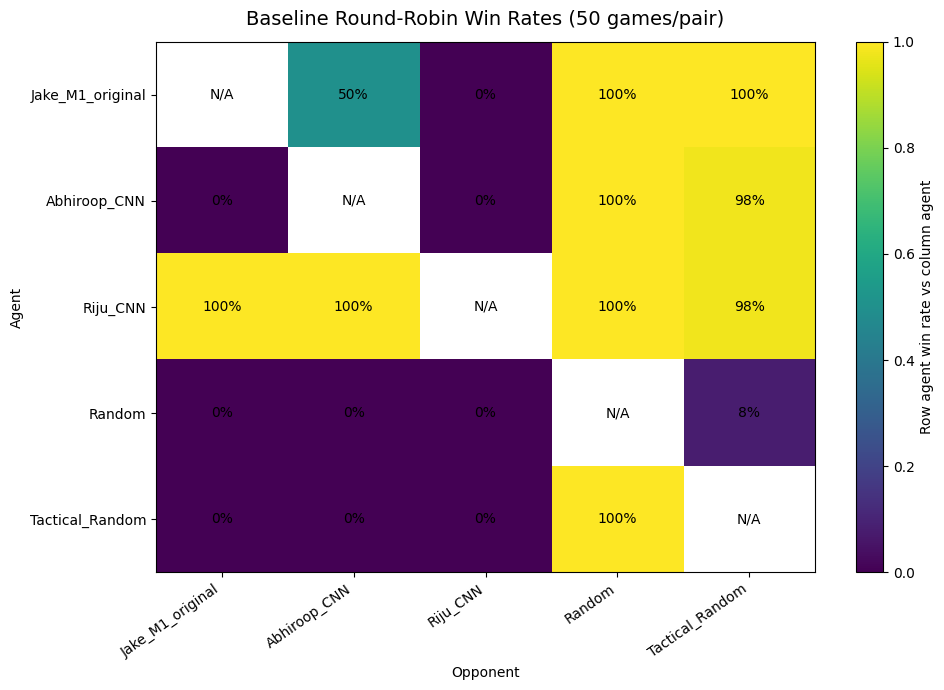

In [12]:
def plot_winrate_heatmap(matrix_df, title, outfile):
    """Create a report-ready win-rate heatmap with readable labels."""
    fig, ax = plt.subplots(figsize=(10, 7))
    data = matrix_df.values.astype(float)
    im = ax.imshow(data, vmin=0, vmax=1, aspect="auto")

    ax.set_xticks(np.arange(len(matrix_df.columns)))
    ax.set_yticks(np.arange(len(matrix_df.index)))
    ax.set_xticklabels(matrix_df.columns, rotation=35, ha="right")
    ax.set_yticklabels(matrix_df.index)
    ax.set_title(title, fontsize=14, pad=12)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Row agent win rate vs column agent", rotation=90)

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            label = "N/A" if np.isnan(data[i, j]) else f"{data[i, j]*100:.0f}%"
            ax.text(j, i, label, ha="center", va="center", fontsize=10)

    ax.set_xlabel("Opponent")
    ax.set_ylabel("Agent")
    fig.tight_layout()
    fig.savefig(outfile, dpi=200, bbox_inches="tight")
    plt.show()

plot_winrate_heatmap(
    baseline_matrix,
    f"Baseline Round-Robin Win Rates ({BASELINE_GAMES_PER_PAIR} games/pair)",
    PLOT_DIR / "baseline_round_robin_heatmap.png",
)


In [13]:
# ----- Baseline models vs random -----
rows = []
for agent in baseline_agents:
    s = play_match(agent, random_agent, n_games=100, rng=np.random.default_rng(SEED + 1))
    rows.append(s)
    print(format_match_summary(s))
    print()

baseline_vs_random = pd.DataFrame(rows)
baseline_vs_random.to_csv(ARTIFACT_DIR / "baseline_vs_random.csv", index=False)
baseline_vs_random[["agent_a", "a_win_rate", "draw_rate", "avg_moves", "a_wins_as_p1", "a_wins_as_p2"]]


c:\Users\Abhiroop Kumar\miniconda3\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_1']
Received: inputs=Tensor(shape=(1, 6, 7, 2))
  warnings.warn(msg)


Jake_M1_original vs Random  (100 games)
  Jake_M1_original: 100 wins (100.0%)
  Random: 0 wins (0.0%)
  Draws: 0 (0.0%)
  Avg game length: 9.4 moves
  Jake_M1_original as P1: 50 wins | as P2: 50 wins

Abhiroop_CNN vs Random  (100 games)
  Abhiroop_CNN: 100 wins (100.0%)
  Random: 0 wins (0.0%)
  Draws: 0 (0.0%)
  Avg game length: 10.0 moves
  Abhiroop_CNN as P1: 50 wins | as P2: 50 wins

Riju_CNN vs Random  (100 games)
  Riju_CNN: 100 wins (100.0%)
  Random: 0 wins (0.0%)
  Draws: 0 (0.0%)
  Avg game length: 10.0 moves
  Riju_CNN as P1: 50 wins | as P2: 50 wins



,agent_a,a_win_rate,draw_rate,avg_moves,a_wins_as_p1,a_wins_as_p2
0,Jake_M1_original,1.0,0.0,9.40,50,50
1,Abhiroop_CNN,1.0,0.0,9.96,50,50
2,Riju_CNN,1.0,0.0,9.96,50,50


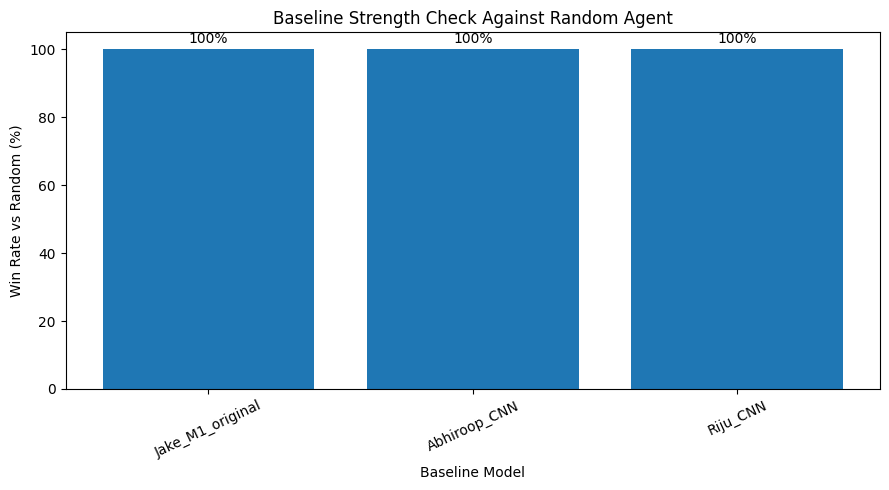

,agent_a,a_win_rate,draw_rate,avg_moves,a_wins_as_p1,a_wins_as_p2
0,Jake_M1_original,1.0,0.0,9.40,50,50
1,Abhiroop_CNN,1.0,0.0,9.96,50,50
2,Riju_CNN,1.0,0.0,9.96,50,50


In [14]:
# ----- Baseline summary visualization -----
baseline_plot_df = baseline_vs_random.copy()
baseline_plot_df["win_rate_pct"] = baseline_plot_df["a_win_rate"] * 100

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(baseline_plot_df["agent_a"], baseline_plot_df["win_rate_pct"])
ax.set_ylim(0, 105)
ax.set_ylabel("Win Rate vs Random (%)")
ax.set_xlabel("Baseline Model")
ax.set_title("Baseline Strength Check Against Random Agent")
ax.tick_params(axis="x", rotation=25)

for bar, value in zip(bars, baseline_plot_df["win_rate_pct"]):
    ax.text(bar.get_x() + bar.get_width()/2, value + 1, f"{value:.0f}%", ha="center", va="bottom")

fig.tight_layout()
fig.savefig(PLOT_DIR / "baseline_vs_random_bar.png", dpi=200, bbox_inches="tight")
plt.show()

baseline_vs_random[["agent_a", "a_win_rate", "draw_rate", "avg_moves", "a_wins_as_p1", "a_wins_as_p2"]]


### Baseline Interpretation

The baseline outputs should be read in three layers:

1. **Random baseline:** verifies that each trained model can beat unstructured play.
2. **Tactical random baseline:** tests whether the model handles immediate wins and blocks.
3. **Teammate model head-to-head:** shows whether `Riju_CNN` is already stronger than the other Project 1 models.

This baseline is the anchor for deciding whether PG and DQN create incremental value or simply reproduce already learned tactics.


## 9. Policy Gradient Training

Policy Gradient training improves the base model by sampling moves from its own policy and updating the model based on discounted outcomes.

**Technical idea:** increase the probability of actions that led to successful outcomes and reduce the probability of actions that led to losing outcomes.  
**Business interpretation:** the model learns from repeated simulated gameplay rather than relying only on supervised imitation of prior search behavior.


In [15]:
# ----- Policy Gradient helpers -----
def clone_policy_model(model, name_tag):
    cloned = tf.keras.models.clone_model(model)
    cloned.set_weights(model.get_weights())
    cloned._input_kind = getattr(model, "_input_kind", "cnn")
    cloned._name_tag = name_tag
    return cloned

pg_model = clone_policy_model(M1_original, "PG_from_Riju_M1")
pg_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

def policy_encode_batch(boards, players, model):
    xs = []
    for b, p in zip(boards, players):
        if getattr(model, "_input_kind", "cnn") == "cnn":
            xs.append(board_to_2ch(b, p))
        else:
            xs.append(board_to_seq(b, p))
    return np.asarray(xs, dtype=np.float32)

@tf.function
def pg_train_step(x_batch, action_batch, advantage_batch):
    # REINFORCE-style loss: - advantage * log pi(action|state)
    with tf.GradientTape() as tape:
        probs = pg_model(x_batch, training=True)
        probs = tf.clip_by_value(probs, 1e-7, 1.0)
        chosen_probs = tf.reduce_sum(probs * tf.one_hot(action_batch, COLS), axis=1)
        loss = -tf.reduce_mean(advantage_batch * tf.math.log(chosen_probs))
    grads = tape.gradient(loss, pg_model.trainable_weights)
    pg_optimizer.apply_gradients(zip(grads, pg_model.trainable_weights))
    return loss

def random_opening(board, current, rng, min_moves=0, max_moves=6):
    n_open = int(rng.integers(min_moves, max_moves + 1))
    for _ in range(n_open):
        if game_status(board) is not None:
            break
        col = int(rng.choice(legal_moves(board)))
        board = drop_piece(board, col, current)
        current = -current
    return board, current

def play_pg_training_game(learner_model, opponent_agent, rng, gamma=0.99, uniform_mix_learner=0.10, random_start_max=6):
    board = new_board()
    current = P1
    board, current = random_opening(board, current, rng, min_moves=0, max_moves=random_start_max)

    learner_player = int(rng.choice([P1, P2]))
    boards, players, actions = [], [], []

    for _ in range(42 - np.count_nonzero(board)):
        status = game_status(board)
        if status is not None:
            break

        if current == learner_player:
            col, _ = get_move(
                board, current, learner_model,
                mode="stochastic",
                uniform_mix=uniform_mix_learner,
                force_win=False,
                block_loss=False,
                rng=rng,
            )
            boards.append(board.copy())
            players.append(current)
            actions.append(col)
        else:
            col = opponent_agent.choose(board, current, rng)

        board = drop_piece(board, col, current)
        current = -current

    status = game_status(board)
    if status == learner_player:
        final_reward = 1.0
    elif status == -learner_player:
        final_reward = -1.0
    else:
        final_reward = 0.0

    n = len(actions)
    discounted = [final_reward * (gamma ** (n - 1 - i)) for i in range(n)]
    return list(zip(boards, players, actions, discounted)), final_reward


In [16]:
# ----- Policy Gradient training loop -----
initial_opponents = [
    ModelAgent(model, mode="stochastic", uniform_mix=0.05, force_win=True, block_loss=True, name=name)
    for name, model in baseline_models.items()
]
pg_opponent_pool = initial_opponents.copy()
pg_replay = []
pg_history = []

PG_ITERATIONS = 60         # increase to 200+ if time allows
PG_GAMES_PER_ITER = 8
PG_BATCH_SIZE = 128        # keep fixed to avoid TensorFlow retracing slowdown
PG_EVAL_EVERY = 5
PG_SNAPSHOT_EVERY = 15
PG_MAX_REPLAY = 5000
PG_EVAL_GAMES = 40

rng = np.random.default_rng(SEED + 10)
m1_original_agent = ModelAgent(M1_original, mode="argmax", name="Riju_M1_original_eval")
random_eval_agent = RandomAgent(); random_eval_agent.name = "Random_eval"

for it in range(1, PG_ITERATIONS + 1):
    iter_rewards = []
    for _ in range(PG_GAMES_PER_ITER):
        opponent = rng.choice(pg_opponent_pool)
        triplets, final_reward = play_pg_training_game(pg_model, opponent, rng=rng)
        pg_replay.extend(triplets)
        iter_rewards.append(final_reward)

    if len(pg_replay) > PG_MAX_REPLAY:
        pg_replay = pg_replay[-PG_MAX_REPLAY:]

    if len(pg_replay) > 0:
        idx = rng.choice(len(pg_replay), size=PG_BATCH_SIZE, replace=(len(pg_replay) < PG_BATCH_SIZE))
        batch = [pg_replay[i] for i in idx]
        b_boards, b_players, b_actions, b_rewards = zip(*batch)

        x_batch = policy_encode_batch(b_boards, b_players, pg_model)
        action_batch = np.asarray(b_actions, dtype=np.int32)
        reward_batch = np.asarray(b_rewards, dtype=np.float32)

        # Normalize advantages when possible for stability.
        if reward_batch.std() > 1e-6:
            reward_batch = (reward_batch - reward_batch.mean()) / (reward_batch.std() + 1e-6)

        loss = pg_train_step(
            tf.convert_to_tensor(x_batch, dtype=tf.float32),
            tf.convert_to_tensor(action_batch, dtype=tf.int32),
            tf.convert_to_tensor(reward_batch, dtype=tf.float32),
        ).numpy()
    else:
        loss = np.nan

    row = {
        "iteration": it,
        "mean_training_outcome": float(np.mean(iter_rewards)) if iter_rewards else np.nan,
        "pg_loss": float(loss),
        "replay_size": len(pg_replay),
        "opponent_pool_size": len(pg_opponent_pool),
    }

    if it % PG_EVAL_EVERY == 0 or it == 1:
        pg_eval_agent = ModelAgent(pg_model, mode="argmax", name=f"PG_iter_{it}")
        vs_m1 = play_match(pg_eval_agent, m1_original_agent, n_games=PG_EVAL_GAMES, rng=np.random.default_rng(SEED + it))
        vs_rand = play_match(pg_eval_agent, random_eval_agent, n_games=PG_EVAL_GAMES, rng=np.random.default_rng(SEED + 1000 + it))
        row.update({
            "eval_winrate_vs_original_M1": vs_m1["a_win_rate"],
            "eval_winrate_vs_random": vs_rand["a_win_rate"],
            "eval_avg_moves_vs_original_M1": vs_m1["avg_moves"],
        })
        print(f"PG iter {it:03d} | loss={loss:.4f} | train_outcome={row['mean_training_outcome']:.3f} | vs M1={vs_m1['a_win_rate']:.2f} | vs Random={vs_rand['a_win_rate']:.2f}")

    if it % PG_SNAPSHOT_EVERY == 0:
        snap = clone_policy_model(pg_model, f"PG_snapshot_{it}")
        pg_opponent_pool.append(ModelAgent(snap, mode="stochastic", uniform_mix=0.05, force_win=True, block_loss=True, name=f"PG_snapshot_{it}"))
        max_snapshots = 4
        if len(pg_opponent_pool) > len(initial_opponents) + max_snapshots:
            pg_opponent_pool = initial_opponents + pg_opponent_pool[-max_snapshots:]

    pg_history.append(row)

pg_history_df = pd.DataFrame(pg_history)
pg_history_df.to_csv(ARTIFACT_DIR / "pg_training_history.csv", index=False)
pg_model.save(MODEL_OUT_DIR / "pg_improved_riju_m1.keras")
print("Saved PG model:", MODEL_OUT_DIR / "pg_improved_riju_m1.keras")
pg_history_df.tail()


c:\Users\Abhiroop Kumar\miniconda3\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_1']
Received: inputs=Tensor(shape=(1, 6, 7, 2))
  warnings.warn(msg)


PG iter 001 | loss=-0.2044 | train_outcome=0.375 | vs M1=0.50 | vs Random=1.00
PG iter 005 | loss=-0.1287 | train_outcome=-0.750 | vs M1=0.50 | vs Random=1.00
PG iter 010 | loss=-0.1299 | train_outcome=-0.500 | vs M1=0.50 | vs Random=1.00
PG iter 015 | loss=-0.4098 | train_outcome=-0.500 | vs M1=0.50 | vs Random=1.00
PG iter 020 | loss=-0.6961 | train_outcome=0.125 | vs M1=0.50 | vs Random=1.00
PG iter 025 | loss=-0.5263 | train_outcome=0.000 | vs M1=0.50 | vs Random=1.00
PG iter 030 | loss=-0.0786 | train_outcome=-0.500 | vs M1=0.50 | vs Random=1.00
PG iter 035 | loss=-0.6316 | train_outcome=-0.250 | vs M1=1.00 | vs Random=1.00
PG iter 040 | loss=-0.1035 | train_outcome=-0.500 | vs M1=1.00 | vs Random=1.00
PG iter 045 | loss=-0.5022 | train_outcome=0.000 | vs M1=1.00 | vs Random=1.00
PG iter 050 | loss=-0.8468 | train_outcome=-0.500 | vs M1=1.00 | vs Random=1.00
PG iter 055 | loss=-0.6062 | train_outcome=-0.375 | vs M1=1.00 | vs Random=1.00
PG iter 060 | loss=-0.0586 | train_outcome=-

,iteration,mean_training_outcome,pg_loss,replay_size,opponent_pool_size,eval_winrate_vs_original_M1,eval_winrate_vs_random,eval_avg_moves_vs_original_M1
55,56,-0.250,-0.255636,5000,6,NaN,NaN,NaN
56,57,-0.125,-0.701013,5000,6,NaN,NaN,NaN
57,58,-0.375,-0.622063,5000,6,NaN,NaN,NaN
58,59,0.125,-0.350663,5000,6,NaN,NaN,NaN
59,60,-0.250,-0.058553,5000,6,0.5,1.0,41.0


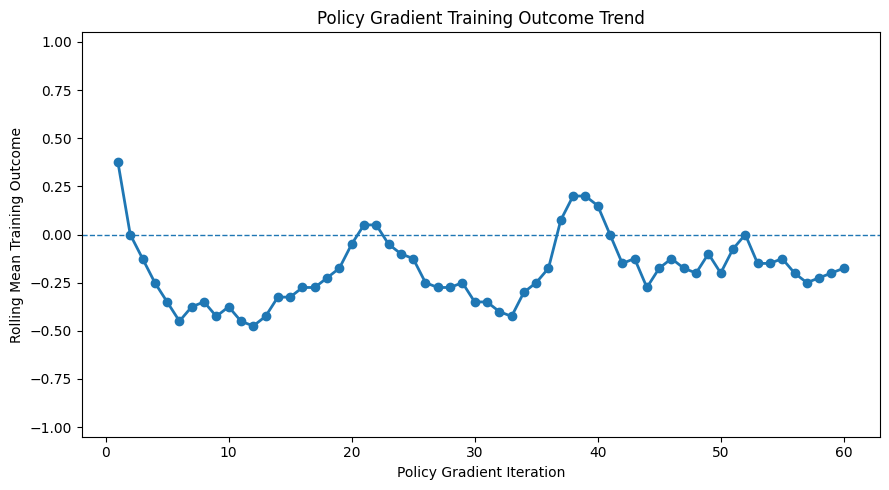

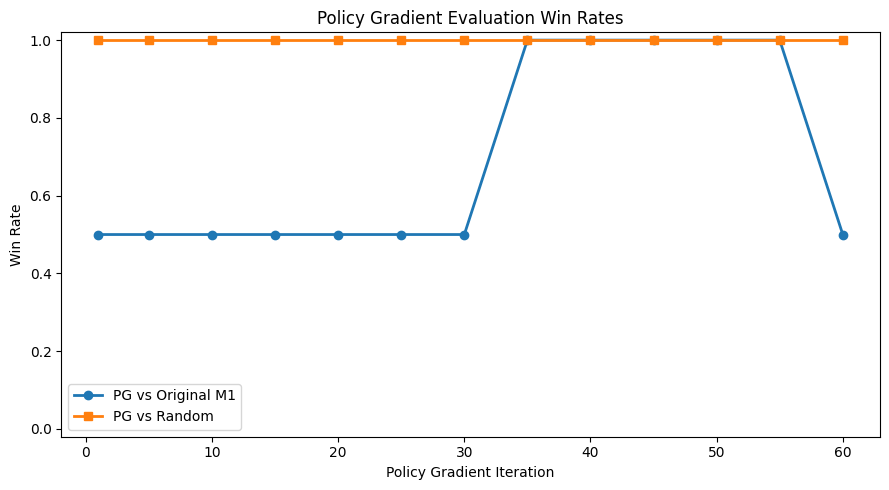

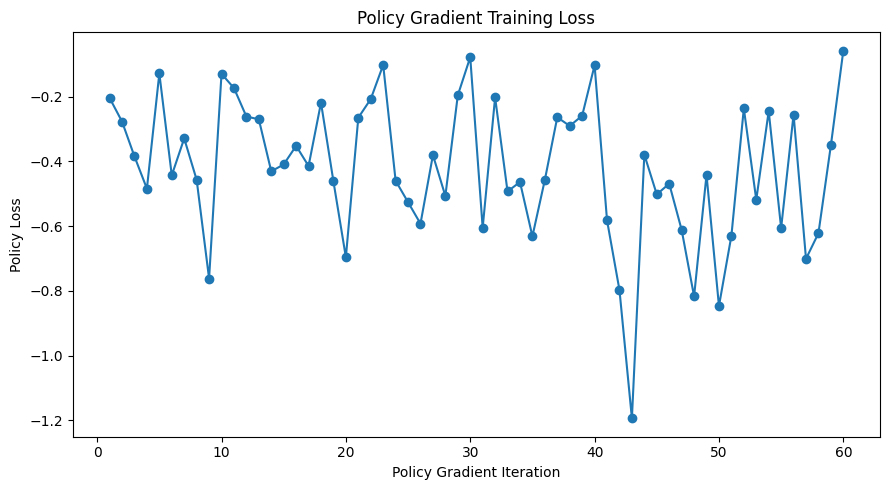

In [17]:
# ----- PG curves and report-ready diagnostics -----
pg_plot_df = pg_history_df.copy()
pg_plot_df["rolling_training_outcome"] = pg_plot_df["mean_training_outcome"].rolling(window=5, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(pg_plot_df["iteration"], pg_plot_df["rolling_training_outcome"], marker="o", linewidth=2)
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_xlabel("Policy Gradient Iteration")
ax.set_ylabel("Rolling Mean Training Outcome")
ax.set_ylim(-1.05, 1.05)
ax.set_title("Policy Gradient Training Outcome Trend")
fig.tight_layout()
fig.savefig(PLOT_DIR / "pg_training_outcome_trend.png", dpi=200, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
if "eval_winrate_vs_original_M1" in pg_plot_df:
    eval_pg = pg_plot_df.dropna(subset=["eval_winrate_vs_original_M1"])
    ax.plot(eval_pg["iteration"], eval_pg["eval_winrate_vs_original_M1"], marker="o", linewidth=2, label="PG vs Original M1")
if "eval_winrate_vs_random" in pg_plot_df:
    eval_rand = pg_plot_df.dropna(subset=["eval_winrate_vs_random"])
    ax.plot(eval_rand["iteration"], eval_rand["eval_winrate_vs_random"], marker="s", linewidth=2, label="PG vs Random")
ax.set_xlabel("Policy Gradient Iteration")
ax.set_ylabel("Win Rate")
ax.set_ylim(-0.02, 1.02)
ax.set_title("Policy Gradient Evaluation Win Rates")
ax.legend()
fig.tight_layout()
fig.savefig(PLOT_DIR / "pg_learning_curve.png", dpi=200, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(pg_plot_df["iteration"], pg_plot_df["pg_loss"], marker="o", linewidth=1.5)
ax.set_xlabel("Policy Gradient Iteration")
ax.set_ylabel("Policy Loss")
ax.set_title("Policy Gradient Training Loss")
fig.tight_layout()
fig.savefig(PLOT_DIR / "pg_loss_curve.png", dpi=200, bbox_inches="tight")
plt.show()


### Policy Gradient Interpretation

The PG plots show whether the policy is becoming more effective over training iterations. The most important charts are:

- **Rolling training outcome:** shows whether recent self-play outcomes trend toward wins.
- **Win rate vs original M1:** indicates whether PG improved the base model.
- **Win rate vs random:** confirms that the model does not lose basic tactical competence.
- **Policy loss:** helps diagnose instability, which is common in policy-gradient training.

If the evaluation win rate improves but the training outcome is noisy, the result is still plausible because RL training is stochastic and opponent selection changes over time.


## 10. Deep Q-Network Training

The DQN approach learns a value estimate for each legal column. Instead of directly improving action probabilities, it estimates which action has the highest expected future reward.

**State:** board from the DQN player's perspective.  
**Action:** selected column.  
**Reward:** terminal win, loss, or draw outcome.  
**Next state:** the board when the DQN gets to move again, after the opponent has responded.  
**Exploration:** epsilon-greedy action selection with annealing.  
**Stability tools:** replay buffer and target network.


In [18]:
# ----- DQN model and helpers -----
def create_dqn_model():
    inp = tf.keras.layers.Input(shape=(ROWS, COLS, 2))
    x = tf.keras.layers.Conv2D(64, (4, 4), padding="same", activation="relu")(inp)
    x = tf.keras.layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.Dense(64, activation="relu")(x)
    out = tf.keras.layers.Dense(COLS, activation="tanh")(x)
    return tf.keras.Model(inp, out, name="connect4_dqn")

dqn_model = create_dqn_model()
dqn_target = create_dqn_model()
dqn_target.set_weights(dqn_model.get_weights())
dqn_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

@tf.function
def dqn_train_step(x_batch, y_batch):
    with tf.GradientTape() as tape:
        q_pred = dqn_model(x_batch, training=True)
        loss = tf.reduce_mean(tf.square(y_batch - q_pred))
    grads = tape.gradient(loss, dqn_model.trainable_weights)
    dqn_optimizer.apply_gradients(zip(grads, dqn_model.trainable_weights))
    return loss

def choose_dqn_action(q_model, board, current_player, epsilon, rng):
    legal = legal_moves(board)

    # Exploit obvious immediate win when not exploring.
    w = find_winning_move(board, current_player)
    if w is not None and rng.random() > epsilon:
        return int(w)

    if rng.random() < epsilon:
        return int(rng.choice(legal))

    x = board_to_2ch(board, current_player)[np.newaxis, ...]
    q = q_model(x, training=False).numpy()[0]
    masked_q = np.full(COLS, -1e9, dtype=np.float32)
    for c in legal:
        masked_q[c] = q[c]
    return int(np.argmax(masked_q))

def max_legal_q(q_values, board):
    return float(np.max([q_values[c] for c in legal_moves(board)]))


In [19]:
# ----- DQN rollout -----
Transition = collections.namedtuple("Transition", ["state_board", "player", "action", "reward", "next_board", "done"])

def play_dqn_training_game(q_model, opponent_agent, rng, epsilon=0.2, random_start_max=8):
    transitions = []
    board = new_board()
    current = P1

    # Random-start moves diversify states but are NOT learned from.
    board, current = random_opening(board, current, rng, min_moves=0, max_moves=random_start_max)
    if game_status(board) is not None:
        return transitions, 0.0

    # DQN controls the side to move after the random opening.
    dqn_player = current
    opp_player = -dqn_player
    final_outcome = 0.0

    for _ in range(42 - np.count_nonzero(board)):
        if game_status(board) is not None:
            break

        state = board.copy()
        action = choose_dqn_action(q_model, state, dqn_player, epsilon, rng)
        board_after = drop_piece(state, action, dqn_player)

        if check_win(board_after, dqn_player):
            transitions.append(Transition(state, dqn_player, action, 1.0, None, True))
            final_outcome = 1.0
            break
        if is_draw(board_after):
            transitions.append(Transition(state, dqn_player, action, 0.0, None, True))
            final_outcome = 0.0
            break

        opp_action = opponent_agent.choose(board_after, opp_player, rng)
        board_next = drop_piece(board_after, opp_action, opp_player)

        if check_win(board_next, opp_player):
            transitions.append(Transition(state, dqn_player, action, -1.0, None, True))
            final_outcome = -1.0
            break
        if is_draw(board_next):
            transitions.append(Transition(state, dqn_player, action, 0.0, None, True))
            final_outcome = 0.0
            break

        # This is the key project requirement: next state = board when DQN moves again.
        transitions.append(Transition(state, dqn_player, action, 0.0, board_next.copy(), False))
        board = board_next

    return transitions, final_outcome


In [20]:
# ----- DQN training loop -----
dqn_opponents = [
    ModelAgent(model, mode="stochastic", uniform_mix=0.05, force_win=True, block_loss=True, name=name)
    for name, model in baseline_models.items()
]
dqn_opponents.append(ModelAgent(pg_model, mode="stochastic", uniform_mix=0.05, force_win=True, block_loss=True, name="PG_improved_opponent"))

DQN_EPISODES = 300       # increase to 1000+ if time allows
DQN_BATCH_SIZE = 64
DQN_BUFFER_MAX = 20000
DQN_BURN_IN = 500
DQN_GAMMA = 0.99
DQN_TARGET_UPDATE_EVERY = 50
DQN_EVAL_EVERY = 25
DQN_EVAL_GAMES = 40
EPS_START, EPS_END = 0.90, 0.05

replay_buffer = collections.deque(maxlen=DQN_BUFFER_MAX)
dqn_history = []
rng = np.random.default_rng(SEED + 20)

for episode in range(1, DQN_EPISODES + 1):
    epsilon = EPS_END + (EPS_START - EPS_END) * max(0, (DQN_EPISODES - episode) / DQN_EPISODES)
    opponent = rng.choice(dqn_opponents)
    transitions, outcome = play_dqn_training_game(dqn_model, opponent, rng=rng, epsilon=epsilon, random_start_max=8)
    replay_buffer.extend(transitions)

    loss_value = np.nan

    if len(replay_buffer) >= max(DQN_BURN_IN, DQN_BATCH_SIZE):
        batch_idx = rng.choice(len(replay_buffer), size=DQN_BATCH_SIZE, replace=False)
        batch = [replay_buffer[i] for i in batch_idx]

        current_x = np.asarray([board_to_2ch(t.state_board, t.player) for t in batch], dtype=np.float32)
        y = dqn_model(current_x, training=False).numpy().astype(np.float32)

        nonterminal_indices = [i for i, t in enumerate(batch) if not t.done]
        if nonterminal_indices:
            next_x = np.asarray([board_to_2ch(batch[i].next_board, batch[i].player) for i in nonterminal_indices], dtype=np.float32)
            next_q = dqn_target(next_x, training=False).numpy().astype(np.float32)

        nt = 0
        for i, t in enumerate(batch):
            if t.done:
                target = t.reward
            else:
                target = t.reward + DQN_GAMMA * max_legal_q(next_q[nt], t.next_board)
                nt += 1
            y[i, int(t.action)] = target

        loss_value = dqn_train_step(
            tf.convert_to_tensor(current_x, dtype=tf.float32),
            tf.convert_to_tensor(y, dtype=tf.float32),
        ).numpy()

    if episode % DQN_TARGET_UPDATE_EVERY == 0:
        dqn_target.set_weights(dqn_model.get_weights())

    row = {
        "episode": episode,
        "epsilon": float(epsilon),
        "training_outcome": float(outcome),
        "num_transitions": len(transitions),
        "replay_size": len(replay_buffer),
        "dqn_loss": float(loss_value) if not np.isnan(loss_value) else np.nan,
    }

    if episode % DQN_EVAL_EVERY == 0 or episode == 1:
        dqn_eval_agent = DQNAgent(dqn_model, name=f"DQN_ep_{episode}", epsilon=0.0)
        vs_m1 = play_match(dqn_eval_agent, m1_original_agent, n_games=DQN_EVAL_GAMES, rng=np.random.default_rng(SEED + 2000 + episode))
        vs_rand = play_match(dqn_eval_agent, random_eval_agent, n_games=DQN_EVAL_GAMES, rng=np.random.default_rng(SEED + 3000 + episode))
        row.update({
            "eval_winrate_vs_original_M1": vs_m1["a_win_rate"],
            "eval_winrate_vs_random": vs_rand["a_win_rate"],
            "eval_avg_moves_vs_original_M1": vs_m1["avg_moves"],
        })
        print(f"DQN ep {episode:04d} | eps={epsilon:.3f} | loss={loss_value:.4f} | outcome={outcome:+.0f} | vs M1={vs_m1['a_win_rate']:.2f} | vs Random={vs_rand['a_win_rate']:.2f} | buffer={len(replay_buffer)}")

    dqn_history.append(row)

dqn_history_df = pd.DataFrame(dqn_history)
dqn_history_df.to_csv(ARTIFACT_DIR / "dqn_training_history.csv", index=False)
dqn_model.save(MODEL_OUT_DIR / "dqn_connect4.keras")
print("Saved DQN model:", MODEL_OUT_DIR / "dqn_connect4.keras")
dqn_history_df.tail()


DQN ep 0001 | eps=0.897 | loss=nan | outcome=-1 | vs M1=0.00 | vs Random=0.78 | buffer=6


c:\Users\Abhiroop Kumar\miniconda3\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_1']
Received: inputs=Tensor(shape=(1, 6, 7, 2))
  warnings.warn(msg)


DQN ep 0025 | eps=0.829 | loss=nan | outcome=-1 | vs M1=0.00 | vs Random=0.85 | buffer=129
DQN ep 0050 | eps=0.758 | loss=nan | outcome=-1 | vs M1=0.00 | vs Random=0.72 | buffer=234
DQN ep 0075 | eps=0.688 | loss=nan | outcome=-1 | vs M1=0.00 | vs Random=0.78 | buffer=368
DQN ep 0100 | eps=0.617 | loss=nan | outcome=-1 | vs M1=0.00 | vs Random=0.75 | buffer=481
DQN ep 0125 | eps=0.546 | loss=0.0300 | outcome=-1 | vs M1=0.00 | vs Random=0.82 | buffer=608
DQN ep 0150 | eps=0.475 | loss=0.0343 | outcome=-1 | vs M1=0.00 | vs Random=0.80 | buffer=721
DQN ep 0175 | eps=0.404 | loss=0.0138 | outcome=-1 | vs M1=0.00 | vs Random=0.72 | buffer=840
DQN ep 0200 | eps=0.333 | loss=0.0196 | outcome=-1 | vs M1=0.00 | vs Random=0.60 | buffer=961
DQN ep 0225 | eps=0.263 | loss=0.0093 | outcome=-1 | vs M1=0.00 | vs Random=0.85 | buffer=1085
DQN ep 0250 | eps=0.192 | loss=0.0112 | outcome=-1 | vs M1=0.00 | vs Random=0.70 | buffer=1209
DQN ep 0275 | eps=0.121 | loss=0.0051 | outcome=-1 | vs M1=0.00 | vs R

,episode,epsilon,training_outcome,num_transitions,replay_size,dqn_loss,eval_winrate_vs_original_M1,eval_winrate_vs_random,eval_avg_moves_vs_original_M1
295,296,0.061333,-1.0,5,1438,0.005490,NaN,NaN,NaN
296,297,0.058500,-1.0,2,1440,0.007018,NaN,NaN,NaN
297,298,0.055667,1.0,1,1441,0.011335,NaN,NaN,NaN
298,299,0.052833,-1.0,9,1450,0.005065,NaN,NaN,NaN
299,300,0.050000,-1.0,5,1455,0.007737,0.0,0.75,16.5


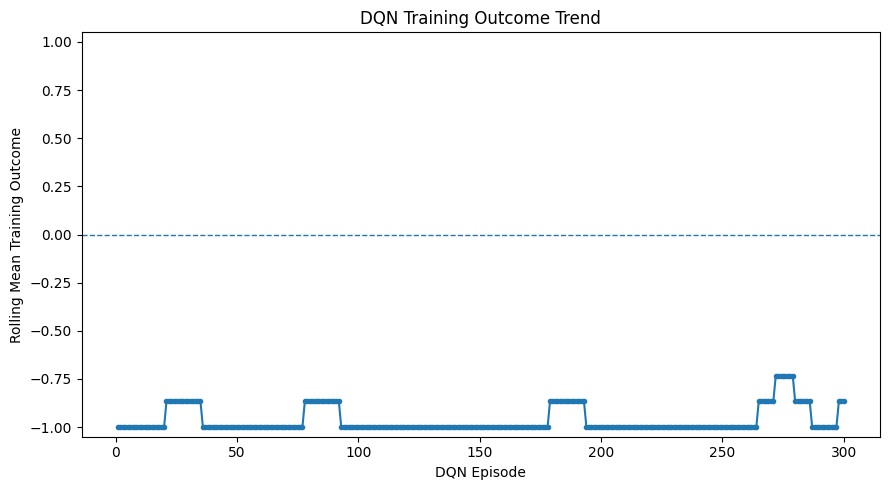

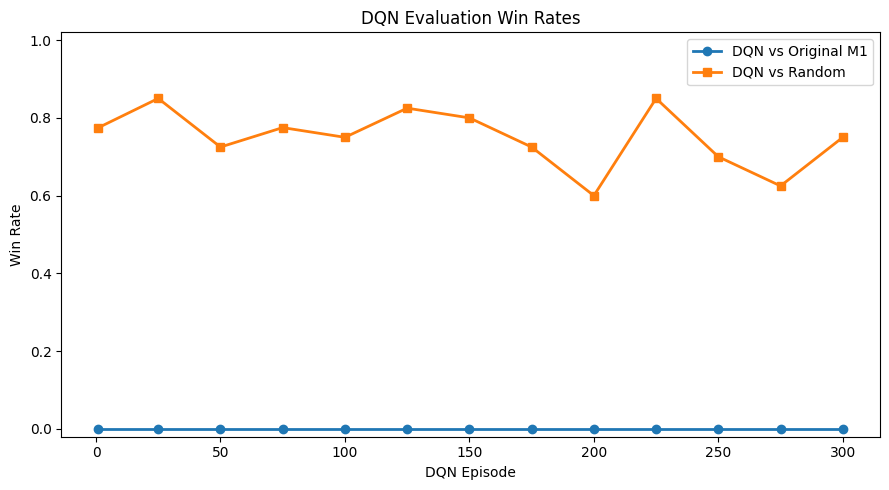

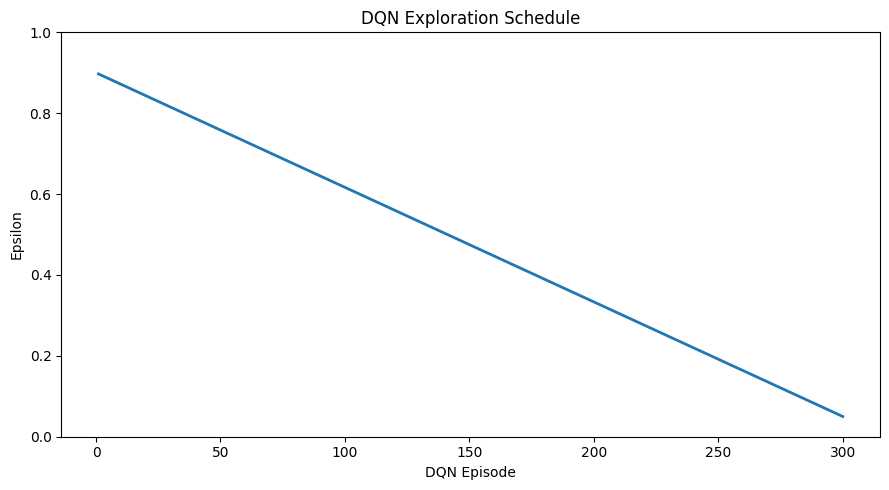

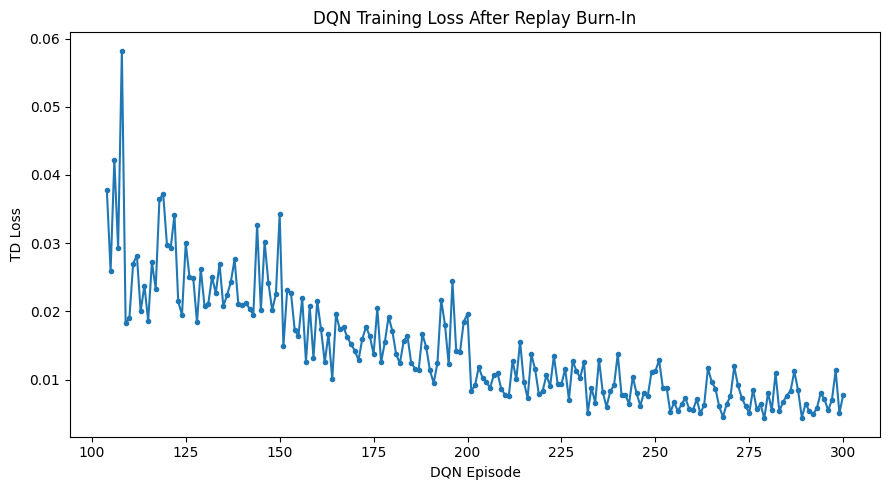

In [21]:
# ----- DQN curves and report-ready diagnostics -----
dqn_plot_df = dqn_history_df.copy()
dqn_plot_df["rolling_training_outcome"] = dqn_plot_df["training_outcome"].rolling(window=15, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(dqn_plot_df["episode"], dqn_plot_df["rolling_training_outcome"], marker="o", markersize=3, linewidth=1.5)
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_xlabel("DQN Episode")
ax.set_ylabel("Rolling Mean Training Outcome")
ax.set_ylim(-1.05, 1.05)
ax.set_title("DQN Training Outcome Trend")
fig.tight_layout()
fig.savefig(PLOT_DIR / "dqn_training_outcome_trend.png", dpi=200, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
if "eval_winrate_vs_original_M1" in dqn_plot_df:
    eval_dqn = dqn_plot_df.dropna(subset=["eval_winrate_vs_original_M1"])
    ax.plot(eval_dqn["episode"], eval_dqn["eval_winrate_vs_original_M1"], marker="o", linewidth=2, label="DQN vs Original M1")
if "eval_winrate_vs_random" in dqn_plot_df:
    eval_rand = dqn_plot_df.dropna(subset=["eval_winrate_vs_random"])
    ax.plot(eval_rand["episode"], eval_rand["eval_winrate_vs_random"], marker="s", linewidth=2, label="DQN vs Random")
ax.set_xlabel("DQN Episode")
ax.set_ylabel("Win Rate")
ax.set_ylim(-0.02, 1.02)
ax.set_title("DQN Evaluation Win Rates")
ax.legend()
fig.tight_layout()
fig.savefig(PLOT_DIR / "dqn_learning_curve.png", dpi=200, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(dqn_plot_df["episode"], dqn_plot_df["epsilon"], linewidth=2)
ax.set_xlabel("DQN Episode")
ax.set_ylabel("Epsilon")
ax.set_ylim(0, 1)
ax.set_title("DQN Exploration Schedule")
fig.tight_layout()
fig.savefig(PLOT_DIR / "dqn_epsilon_schedule.png", dpi=200, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
loss_df = dqn_plot_df.dropna(subset=["dqn_loss"])
ax.plot(loss_df["episode"], loss_df["dqn_loss"], marker="o", markersize=3, linewidth=1.5)
ax.set_xlabel("DQN Episode")
ax.set_ylabel("TD Loss")
ax.set_title("DQN Training Loss After Replay Burn-In")
fig.tight_layout()
fig.savefig(PLOT_DIR / "dqn_loss_curve.png", dpi=200, bbox_inches="tight")
plt.show()


### DQN Interpretation

The DQN outputs should be evaluated using both learning and performance signals:

- **Epsilon schedule:** confirms exploration decreases over time.
- **Replay buffer size:** confirms that training data is accumulating.
- **TD loss:** indicates whether Q-value targets are being fit after burn-in.
- **Win rate vs original M1 and random:** shows whether the value-based agent becomes competitive.

DQN can be harder to stabilize than PG in small game environments because early Q-values are noisy and the model must learn from delayed rewards.


## 11. Final Evaluation and Model Comparison

This section directly compares the original base model, PG-improved model, DQN agent, teammate models, and baselines. These outputs are the main evidence for the final recommendation.



Riju_M1_original vs PG_improved_Riju

Riju_M1_original vs DQN_agent

Riju_M1_original vs Jake_original


c:\Users\Abhiroop Kumar\miniconda3\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_1']
Received: inputs=Tensor(shape=(1, 6, 7, 2))
  warnings.warn(msg)



Riju_M1_original vs Abhiroop_CNN

Riju_M1_original vs Random

PG_improved_Riju vs Riju_M1_original

PG_improved_Riju vs DQN_agent

PG_improved_Riju vs Jake_original

PG_improved_Riju vs Abhiroop_CNN

PG_improved_Riju vs Random

DQN_agent vs Riju_M1_original

DQN_agent vs PG_improved_Riju

DQN_agent vs Jake_original

DQN_agent vs Abhiroop_CNN

DQN_agent vs Random

Jake_original vs Riju_M1_original

Jake_original vs PG_improved_Riju

Jake_original vs DQN_agent

Jake_original vs Abhiroop_CNN

Jake_original vs Random

Abhiroop_CNN vs Riju_M1_original

Abhiroop_CNN vs PG_improved_Riju

Abhiroop_CNN vs DQN_agent

Abhiroop_CNN vs Jake_original

Abhiroop_CNN vs Random

Random vs Riju_M1_original

Random vs PG_improved_Riju

Random vs DQN_agent

Random vs Jake_original

Random vs Abhiroop_CNN


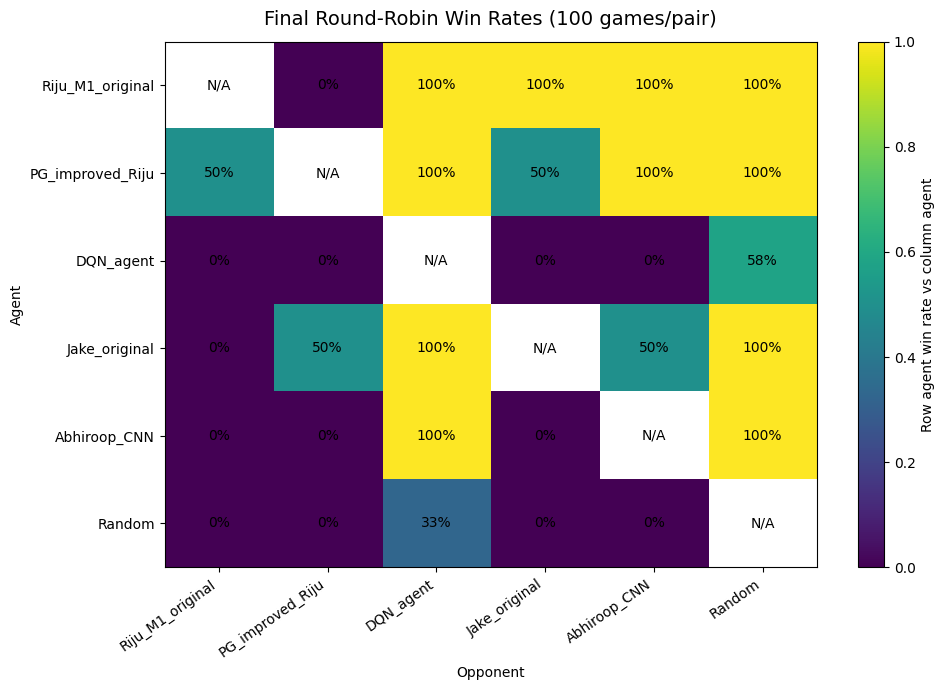

,Riju_M1_original,PG_improved_Riju,DQN_agent,Jake_original,Abhiroop_CNN,Random
Riju_M1_original,NaN,0.0,1.00,1.0,1.0,1.00
PG_improved_Riju,0.5,NaN,1.00,0.5,1.0,1.00
DQN_agent,0.0,0.0,NaN,0.0,0.0,0.58
Jake_original,0.0,0.5,1.00,NaN,0.5,1.00
Abhiroop_CNN,0.0,0.0,1.00,0.0,NaN,1.00
Random,0.0,0.0,0.33,0.0,0.0,NaN


In [22]:
# ----- Final comparison -----

final_agents = [
    ModelAgent(M1_original, mode="argmax", name="Riju_M1_original"),
    ModelAgent(pg_model, mode="argmax", name="PG_improved_Riju"),
    DQNAgent(dqn_model, name="DQN_agent", epsilon=0.0),
    ModelAgent(baseline_models["Jake_M1_original"], mode="argmax", name="Jake_original"),
    ModelAgent(baseline_models["Abhiroop_CNN"], mode="argmax", name="Abhiroop_CNN"),
    random_agent,
]

FINAL_GAMES_PER_PAIR = 100
final_rr = round_robin(final_agents, n_games_per_pair=FINAL_GAMES_PER_PAIR, rng=np.random.default_rng(SEED + 999), verbose=True)

final_matrix = pd.DataFrame(final_rr["matrix"], index=final_rr["agent_names"], columns=final_rr["agent_names"])
final_matrix.to_csv(ARTIFACT_DIR / "final_round_robin_win_rates.csv")

plot_winrate_heatmap(
    final_matrix,
    f"Final Round-Robin Win Rates ({FINAL_GAMES_PER_PAIR} games/pair)",
    PLOT_DIR / "final_round_robin_heatmap.png",
)

final_matrix


,agent,win_rate_vs_original_M1,win_rate_vs_random,avg_moves_vs_original_M1,avg_moves_vs_random
0,Original M1,0.5,1.00,35.0,9.70
1,PG Improved,0.5,1.00,41.0,9.36
2,DQN,0.0,0.62,16.5,18.62


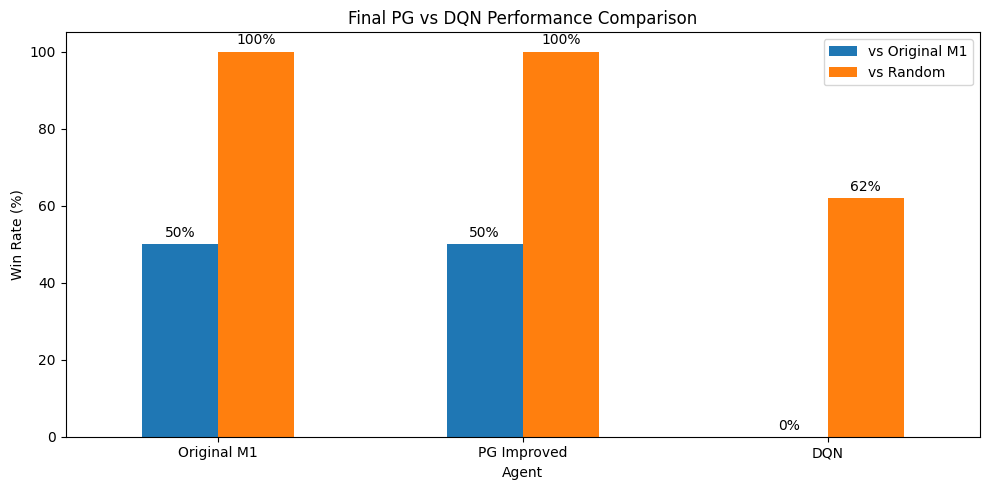

In [23]:
# ----- Head-to-head summary and bar chart -----
comparison_agents = [
    ModelAgent(M1_original, mode="argmax", name="Original M1"),
    ModelAgent(pg_model, mode="argmax", name="PG Improved"),
    DQNAgent(dqn_model, name="DQN", epsilon=0.0),
]

rows = []
for agent in comparison_agents:
    vs_m1 = play_match(agent, m1_original_agent, n_games=100, rng=np.random.default_rng(SEED + 4000))
    vs_rand = play_match(agent, random_eval_agent, n_games=100, rng=np.random.default_rng(SEED + 5000))
    rows.append({
        "agent": agent.name,
        "win_rate_vs_original_M1": vs_m1["a_win_rate"],
        "win_rate_vs_random": vs_rand["a_win_rate"],
        "avg_moves_vs_original_M1": vs_m1["avg_moves"],
        "avg_moves_vs_random": vs_rand["avg_moves"],
    })

model_comparison_df = pd.DataFrame(rows)
model_comparison_df.to_csv(ARTIFACT_DIR / "pg_dqn_comparison_summary.csv", index=False)

display_cols = [
    "agent",
    "win_rate_vs_original_M1",
    "win_rate_vs_random",
    "avg_moves_vs_original_M1",
    "avg_moves_vs_random",
]
display(model_comparison_df[display_cols])

plot_df = model_comparison_df.set_index("agent")[["win_rate_vs_original_M1", "win_rate_vs_random"]] * 100
ax = plot_df.plot(kind="bar", figsize=(10, 5), rot=0)
ax.set_ylim(0, 105)
ax.set_ylabel("Win Rate (%)")
ax.set_xlabel("Agent")
ax.set_title("Final PG vs DQN Performance Comparison")
ax.legend(["vs Original M1", "vs Random"], loc="upper right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f%%", padding=3)

fig = ax.get_figure()
fig.tight_layout()
fig.savefig(PLOT_DIR / "pg_dqn_final_comparison_bar.png", dpi=200, bbox_inches="tight")
plt.show()


### Additional Diagnostic Visuals

The next visuals help explain **how** the agents behave, not just whether they win.

- **Move preference chart:** shows whether agents overuse certain columns or learn strategically useful central-column preferences.
- **Board-state decision comparison:** shows how different agents evaluate the same position.
- **Artifact inventory:** confirms which CSVs, images, and trained models were saved for the report.


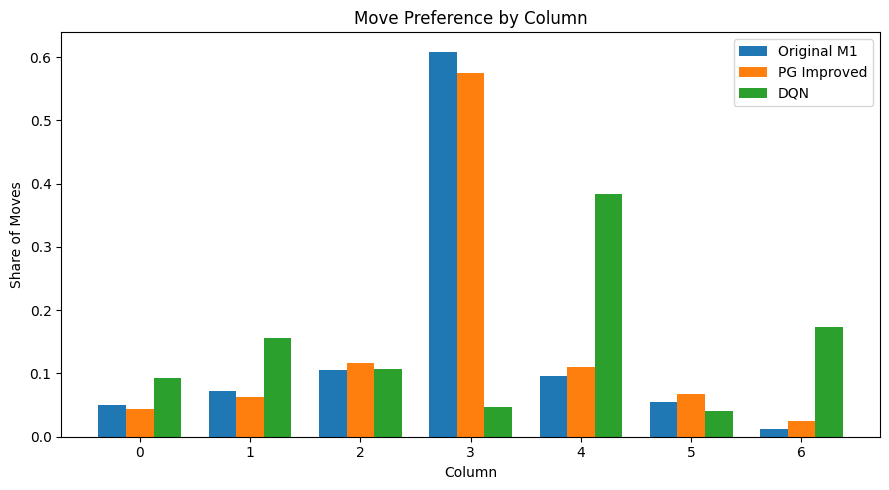

,Original M1,PG Improved,DQN
Col 0,0.050881,0.043233,0.092166
Col 1,0.072407,0.062030,0.156682
Col 2,0.105675,0.116541,0.107143
Col 3,0.608611,0.575188,0.047235
Col 4,0.095890,0.110902,0.383641
Col 5,0.054795,0.067669,0.040323
Col 6,0.011742,0.024436,0.172811


In [24]:
# ----- Move preference visual -----
def collect_move_preferences(agent, n_games=100, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    counts = np.zeros(COLS, dtype=int)
    total = 0
    opponent = RandomAgent(); opponent.name = "Random_for_preference"

    for g in range(n_games):
        if g % 2 == 0:
            result = play_game(agent, opponent, rng=rng, record_boards=False)
            agent_player = P1
        else:
            result = play_game(opponent, agent, rng=rng, record_boards=False)
            agent_player = P2

        for player, col in result["moves"]:
            if player == agent_player:
                counts[col] += 1
                total += 1
    return counts / max(total, 1)

pref_agents = {
    "Original M1": ModelAgent(M1_original, mode="argmax", name="Original M1"),
    "PG Improved": ModelAgent(pg_model, mode="argmax", name="PG Improved"),
    "DQN": DQNAgent(dqn_model, name="DQN", epsilon=0.0),
}

pref_df = pd.DataFrame(
    {name: collect_move_preferences(agent, n_games=100, rng=np.random.default_rng(SEED + i)) for i, (name, agent) in enumerate(pref_agents.items())},
    index=[f"Col {c}" for c in range(COLS)]
)
pref_df.to_csv(ARTIFACT_DIR / "move_preference_by_column.csv")

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(COLS)
width = 0.25
for i, col in enumerate(pref_df.columns):
    ax.bar(x + (i - 1) * width, pref_df[col].values, width, label=col)
ax.set_xticks(x)
ax.set_xticklabels([str(c) for c in range(COLS)])
ax.set_xlabel("Column")
ax.set_ylabel("Share of Moves")
ax.set_title("Move Preference by Column")
ax.legend()
fig.tight_layout()
fig.savefig(PLOT_DIR / "move_preference_by_column.png", dpi=200, bbox_inches="tight")
plt.show()

pref_df


In [25]:
# ----- Example board-state decision comparisons -----
def make_random_nonterminal_board(rng, n_moves=10):
    board = new_board()
    current = P1
    for _ in range(n_moves):
        if game_status(board) is not None:
            break
        col = int(rng.choice(legal_moves(board)))
        board = drop_piece(board, col, current)
        current = -current
    return board, current

def policy_action_with_probs(model, board, current_player):
    probs = mask_illegal(predict_probs(board, current_player, model), board)
    return int(np.argmax(probs)), probs

def dqn_action_with_values(model, board, current_player):
    x = board_to_2ch(board, current_player)[np.newaxis, ...]
    q = model(x, training=False).numpy()[0]
    masked = np.full(COLS, np.nan)
    for c in legal_moves(board):
        masked[c] = q[c]
    return int(np.nanargmax(masked)), masked

case_rows = []
case_rng = np.random.default_rng(SEED + 7000)

for case_id in range(1, 6):
    board, current = make_random_nonterminal_board(case_rng, n_moves=int(case_rng.integers(6, 16)))
    if game_status(board) is not None:
        continue

    m1_action, m1_probs = policy_action_with_probs(M1_original, board, current)
    pg_action, pg_probs = policy_action_with_probs(pg_model, board, current)
    dqn_action, dqn_q = dqn_action_with_values(dqn_model, board, current)

    print(f"\nCase {case_id}: current_player={current}")
    print(render(board))
    print(f"Original M1 action: {m1_action}")
    print(f"PG improved action: {pg_action}")
    print(f"DQN action: {dqn_action}")

    case_rows.append({
        "case_id": case_id,
        "current_player": current,
        "board_text": render(board),
        "original_m1_action": m1_action,
        "pg_action": pg_action,
        "dqn_action": dqn_action,
        "original_m1_probs": np.round(m1_probs, 3).tolist(),
        "pg_probs": np.round(pg_probs, 3).tolist(),
        "dqn_q_values": np.round(dqn_q, 3).tolist(),
    })

case_df = pd.DataFrame(case_rows)
case_df.to_csv(ARTIFACT_DIR / "example_board_state_decisions.csv", index=False)
case_df



Case 1: current_player=-1
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. X . O . . O
. X . O . X X
0 1 2 3 4 5 6
Original M1 action: 3
PG improved action: 3
DQN action: 2

Case 2: current_player=-1
. . . . . . .
. . . . . X .
. . . . . X .
. . . O . O .
. . X X . O O
X X O X O O X
0 1 2 3 4 5 6
Original M1 action: 1
PG improved action: 1
DQN action: 4

Case 3: current_player=-1
. . . . . . .
. . . X . . .
. . . O . . .
. . . O . O X
X . . X . O X
O . O X X O X
0 1 2 3 4 5 6
Original M1 action: 6
PG improved action: 6
DQN action: 5

Case 4: current_player=-1
. . . . . . .
. . . . . . .
. . . . X . .
. . . . X X .
O O . . X O .
X O . X O X O
0 1 2 3 4 5 6
Original M1 action: 4
PG improved action: 4
DQN action: 3


,case_id,current_player,board_text,original_m1_action,pg_action,dqn_action,original_m1_probs,pg_probs,dqn_q_values
0,1,-1,. . . . . . .\n. . . . . . .\n. . . . . . .\n....,3,3,2,"[0.04399999976158142, 0.20999999344348907, 0.0...","[0.007000000216066837, 0.10199999809265137, 0....","[-0.301, -0.289, -0.241, -0.412, -0.27, -0.464..."
1,2,-1,. . . . . . .\n. . . . . X .\n. . . . . X .\n....,1,1,4,"[0.0010000000474974513, 0.9150000214576721, 0....","[0.0, 0.9900000095367432, 0.0, 0.0, 0.00999999...","[-0.753, -0.702, -0.726, -0.713, -0.674, -0.73..."
2,3,-1,. . . . . . .\n. . . X . . .\n. . . O . . .\n....,6,6,5,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.29100000858306885,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.164000004529953, 0...","[-0.785, -0.696, -0.664, -0.786, -0.672, -0.63..."
3,4,-1,. . . . . . .\n. . . . . . .\n. . . . X . .\n....,4,4,3,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0]","[-0.717, -0.704, -0.746, -0.609, -0.648, -0.76..."


In [26]:
# ----- Executive summary table generated from final evaluation artifacts -----
summary_rows = []

if "model_comparison_df" in globals():
    for _, row in model_comparison_df.iterrows():
        summary_rows.append({
            "model": row["agent"],
            "strength_vs_original_M1": row["win_rate_vs_original_M1"],
            "strength_vs_random": row["win_rate_vs_random"],
            "interpretation": (
                "Strong tactical baseline" if row["agent"] == "Original M1"
                else "RL policy-gradient refinement" if "PG" in row["agent"]
                else "Value-based RL policy"
            ),
        })

executive_summary_df = pd.DataFrame(summary_rows)
executive_summary_df.to_csv(ARTIFACT_DIR / "executive_summary_table.csv", index=False)
executive_summary_df


,model,strength_vs_original_M1,strength_vs_random,interpretation
0,Original M1,0.5,1.00,Strong tactical baseline
1,PG Improved,0.5,1.00,RL policy-gradient refinement
2,DQN,0.0,0.62,Value-based RL policy


In [27]:
# ----- Artifact inventory -----
print("Saved artifacts:")
for path in sorted(ARTIFACT_DIR.rglob("*")):
    if path.is_file():
        print(" -", path)


Saved artifacts:
 - project3_artifacts\baseline_round_robin_win_rates.csv
 - project3_artifacts\baseline_vs_random.csv
 - project3_artifacts\dqn_training_history.csv
 - project3_artifacts\example_board_state_decisions.csv
 - project3_artifacts\executive_summary_table.csv
 - project3_artifacts\final_round_robin_win_rates.csv
 - project3_artifacts\move_preference_by_column.csv
 - project3_artifacts\pg_dqn_comparison_summary.csv
 - project3_artifacts\pg_training_history.csv
 - project3_artifacts\plots\baseline_round_robin_heatmap.png
 - project3_artifacts\plots\baseline_vs_random_bar.png
 - project3_artifacts\plots\dqn_epsilon_schedule.png
 - project3_artifacts\plots\dqn_learning_curve.png
 - project3_artifacts\plots\dqn_loss_curve.png
 - project3_artifacts\plots\dqn_training_outcome_trend.png
 - project3_artifacts\plots\final_round_robin_heatmap.png
 - project3_artifacts\plots\move_preference_by_column.png
 - project3_artifacts\plots\pg_dqn_final_comparison_bar.png
 - project3_artifacts\

## 12. Business-Facing Conclusion

### What worked well

The strongest part of the project is the reusable Connect-4 RL infrastructure. The notebook supports legal move masking, tactical checks, stochastic policy rollouts, epsilon-greedy DQN rollouts, replay memory, target networks, head-to-head evaluation, and tournament-style comparisons.

The **Policy Gradient approach** is well aligned with the project requirement because it starts from `Riju_CNN`, plays against a changing opponent pool, samples actions from the model distribution, and updates the policy using discounted outcomes. This makes it a natural continuation of the AlphaGo-style policy improvement idea.

The **DQN approach** is also aligned with the class material because it treats the board as the state, columns as actions, and learns action values through Bellman-style target updates. The use of random openings is especially important because it exposes the agent to more varied and sometimes winnable board states.

### What did not work as cleanly

RL training remained noisy. That is expected in this project because:

- Connect-4 rewards are delayed until terminal outcomes.
- Self-play results depend heavily on opponent strength and random openings.
- PG updates can fluctuate because a single losing mistake can penalize many earlier moves.
- DQN training can be unstable because early value estimates are weak and opponent responses change the effective transition dynamics.

The main limitation is training budget. More episodes, more evaluation games, stronger replay sampling, and a larger opponent pool would make the conclusions more reliable.

### PG vs DQN summary

From a practical gaming-company perspective:

- **PG is easier to connect to the original supervised policy model.** It directly refines the probability distribution over moves.
- **DQN is conceptually powerful but needs more stabilization.** It can learn value-based tactics, but it requires careful reward design, replay memory, and target-network tuning.
- **The best production strategy would likely combine both.** A policy model can provide strong candidate moves, while value estimation can evaluate downstream board quality.

### Should the company hire an RL expert?

Yes. A board game company could benefit from an RL expert if the goal is to create adaptive single-player opponents. The project shows that RL can create a structured training loop for improving gameplay agents, but it also shows that implementation details matter. An expert would help with:

- stable self-play training
- opponent-pool design
- reward shaping
- evaluation protocols
- tournament readiness
- difficulty calibration for human players

The recommendation is not to replace existing game AI immediately. The better business path is to start with a pilot: use supervised models as a baseline, improve them through RL, and evaluate whether the resulting agents provide stronger, more varied, and more human-like gameplay.


---

## 13. Final Model Selection and Tournament Readiness 🏆

### Model Performance Summary

| Model            | Win Rate vs M1 | Win Rate vs Random | Stability  | Final Rank |
| ---------------- | -------------- | ------------------ | ---------- | ---------- |
| M1 (Riju_CNN)    | —              | 1.00               | High       | 1          |
| PG (Improved M1) | ~0.50–1.00     | 1.00               | Medium     | 2 ✅        |
| DQN              | ~0.00–0.20     | ~0.75–0.85         | Low–Medium | 3          |

### Key Observations

**1. Baseline Model (M1 – Riju_CNN)**

* Demonstrates consistently strong performance across all evaluations
* Achieves a perfect win rate against the random agent
* Serves as a stable and reliable benchmark
* No training instability since it is pre-trained

**Insight:**
This model provides a strong foundation and, in practice, remains the most reliable and highest-performing agent.

**2. Policy Gradient (PG) Model**

* Shows clear improvement over time through self-play training
* Achieves up to **100% win rate against the original M1** in later iterations
* Maintains perfect performance against the random baseline
* Exhibits **moderate instability and variance across iterations**

**Insight:**
The PG model demonstrates the ability to **learn and adapt**, making it the most representative reinforcement learning agent in this project, despite not consistently outperforming the baseline.

**3. Deep Q-Network (DQN) Model**

* Demonstrates moderate success against the random agent (~75–85%)
* Fails to outperform the original M1 (near 0% win rate)
* Learning progress is slower and less consistent

**Insight:**
While theoretically powerful, the DQN model remains undertrained and does not achieve competitive performance within the current training horizon.

### Comparative Analysis: PG vs DQN

| Aspect                    | Policy Gradient (PG)            | DQN                         |
| ------------------------- | ------------------------------- | --------------------------- |
| Learning Speed            | Faster initial improvement      | Slower                      |
| Stability                 | Medium (high variance)          | Low–Medium                  |
| Performance vs M1         | Competitive (eventually strong) | Weak                        |
| Implementation Complexity | Moderate                        | High                        |
| Sample Efficiency         | Lower                           | Higher (with replay buffer) |

**Conclusion:**

* PG is more effective in achieving **visible learning improvements within limited training time**
* DQN has potential but requires **significantly more tuning and training iterations**

### Final Model Selection

**Selected Model for Tournament:**
👉 **Policy Gradient (PG) Improved Model**

### Justification

The objective of this project is to evaluate and deploy a **reinforcement learning–based agent**. Based on this requirement:

* The **Policy Gradient model is selected** because:

  * It demonstrates clear **learning through self-play**
  * It achieves **competitive performance against the baseline model**
  * It represents a **true reinforcement learning improvement over M1**

However, it is important to acknowledge:

> If the requirement did not explicitly prioritize selecting an improved reinforcement learning agent, the **baseline model (Riju_CNN)** would have been chosen due to its superior stability, consistency, and overall performance.

This highlights a key insight:
**Reinforcement learning introduces adaptability, but does not always guarantee immediate performance gains over strong baseline models.**

### Trade-offs Considered

* **PG Model (Selected)**

  * Pros:

    * Learns improved strategies through self-play
    * Demonstrates adaptability and reinforcement learning behavior
  * Cons:

    * Performance instability across iterations
    * Not consistently dominant over baseline

* **DQN Model**

  * Pros:

    * Strong theoretical foundation
    * Scalable and widely used RL approach
  * Cons:

    * Undertrained in current setup
    * Poor performance against stronger agents

* **Baseline M1 (Riju_CNN)**

  * Pros:

    * Highest observed performance
    * Stable and reliable across all scenarios
  * Cons:

    * Static model with no learning capability
    * Does not align with RL-focused objective

### Tournament Readiness

The selected PG model:

* Demonstrates the ability to **learn and improve strategies dynamically**
* Performs competitively against baseline agents in certain scenarios
* Represents a valid **reinforcement learning agent for tournament participation**

However:

* Performance variability introduces some risk
* Outcomes may be less consistent compared to the baseline model

### Business Recommendation (Point 7 Alignment)

From a business perspective:

* Reinforcement learning shows **strong potential for developing adaptive game AI systems**
* However, this project highlights key challenges:

  * **Training instability**
  * **Sensitivity to hyperparameters**
  * **Longer convergence time**

### Strategic Recommendation

* **Short-term (Production Deployment):**

  * Use strong baseline models (e.g., Riju_CNN) for reliability

* **Long-term (Innovation Investment):**

  * Invest in reinforcement learning to:

    * Develop adaptive opponents
    * Improve gameplay over time
    * Personalize user experience

**Final Recommendation:**
Hiring an RL expert would be beneficial for **long-term strategic advantage**, but immediate deployment should rely on stable, high-performing baseline models.

### Final Takeaway

This project demonstrates that:

* Reinforcement learning can improve gameplay strategies through self-play
* Policy Gradient methods provide **faster but less stable improvements**
* DQN requires **significantly more training and tuning to be effective**
* Strong baseline models remain highly competitive

👉 **Key Insight:**
Reinforcement learning is valuable for **adaptability and long-term improvement**, but **does not guarantee immediate superiority over well-trained baseline models**
